# Skenario Uji Awal — Deteksi Sarkasme pada Dataset SARC

Notebook ini menjalankan skenario uji yang diminta dosen pada bimbingan pertama. Ada tiga hal yang dibandingkan:

1. **Input**: comment saja vs parent + comment.
2. **Model**: RoBERTa vs DistilBERT.
3. **Jumlah layer yang dilatih** (*unfreeze*): RoBERTa 0, 3, 6, 12 dan DistilBERT 0, 3, 6.

Semua kombinasi dijalankan, jadi ada **14 kombinasi**. Khusus level 0 dicoba dengan dua *learning rate*, sehingga totalnya **18 percobaan**.

**Alur kerja:**

```
data/tokenized + data/tokenized_comment (train_pilot 40.000 + val 20.000)
   → Susun daftar 18 percobaan
   → Latih tiap percobaan 3 epoch, nilai di data validasi tiap epoch
   → Ukur waktu training, memori GPU, dan latensi
   → Simpan hasil, lalu bandingkan (input, model, jumlah layer)
```

**Dijalankan di:** PC AI Lab, GPU NVIDIA RTX 5070 Ti
**Input:** `data/tokenized/` (parent + comment) dan `data/tokenized_comment/` (comment saja)
**Output:** `data/firstScenario/skenario_runs.csv` (ringkasan tiap percobaan) dan `skenario_history.csv` (hasil per epoch)

> **Penting:** percobaan ini memakai data latih pilot (40.000 pasangan), satu seed, dan dinilai di data validasi. Hasilnya adalah bahan diskusi bimbingan, belum hasil akhir penelitian. Skenario comment saja dan pengaturan jumlah layer tidak tertulis di proposal; keduanya dijalankan atas arahan dosen. Skenario utama proposal (parent + comment, semua layer dilatih) termasuk di dalamnya.

## 1. Hubungkan Google Drive (tidak dipakai di PC lab)

Sel ini sisa dari versi Google Colab. Di PC lab data dibaca langsung dari folder proyek, jadi barisnya dijadikan komentar.

In [39]:
#from google.colab import drive
#drive.mount("/content/drive")

## 2. Setup & Konfigurasi

| Konfigurasi | Nilai | Keterangan |
|---|---|---|
| `DEBUG` | False | Kalau `True`, notebook hanya memakai 300 data dan 1 epoch untuk mengecek kode |
| `TRAIN_SPLIT` | train_pilot | Data latih 40.000 pasangan. Ganti ke `train` untuk data penuh (160.000) |
| `UNFREEZE_LEVELS` | RoBERTa 0, 3, 6, 12; DistilBERT 0, 3, 6 | Jumlah layer teratas yang dilatih |
| `LR_DEFAULT` | 3e-5 | Learning rate terbaik dari pilot |
| `LR_HEAD_ONLY` | 1e-4 dan 1e-3 | Khusus level 0, karena yang dilatih hanya lapisan klasifikasi |
| `NUM_EPOCHS` | 3 | Model membaca seluruh data latih sebanyak 3 kali |
| `BATCH_SIZE` | 32 | Jumlah data yang diproses sekaligus dalam satu langkah |
| `WARMUP_RATIO` | 0,1 | 10% langkah pertama dipakai untuk menaikkan learning rate pelan-pelan |
| `WEIGHT_DECAY` | 0,01 | Membantu mengurangi overfitting |
| `USE_FP16` | True | *Mixed precision*, sesuai proposal |
| `SEED` | 42 | Supaya hasil bisa diulang |

**Arti "jumlah layer yang dilatih".** Model seperti RoBERTa tersusun dari lapisan-lapisan yang bertumpuk (RoBERTa 12 lapis, DistilBERT 6 lapis), dan di paling atas ada lapisan klasifikasi. *Unfreeze* 3 berarti hanya 3 lapis teratas dan lapisan klasifikasi yang dilatih, sedangkan sisanya dikunci (tidak berubah). Ibaratnya merenovasi gedung: level 0 hanya mengganti atap, level 3 merenovasi tiga lantai teratas, dan level tertinggi merenovasi seluruh gedung.

Level 0, 3, dan 6 dipilih supaya kedua model bisa dibandingkan dengan jumlah layer yang sama, dan level tertinggi (12 untuk RoBERTa, 6 untuk DistilBERT) adalah *full fine-tuning* seperti di proposal.

In [53]:
import gc, json, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import transformers
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, Trainer, TrainerCallback,
                          TrainingArguments, set_seed)

transformers.logging.set_verbosity_error()      # sembunyikan LOAD REPORT yang berulang

DEBUG = False                             # True = uji cepat dengan data sangat kecil
TRAIN_SPLIT = "train_pilot"               # "train_pilot" = 40.000 data | "train" = 160.000 data (penuh)

SEED = 42
MODELS = {
    "roberta": "roberta-base",
    "distilbert": "distilbert-base-uncased",
}
UNFREEZE_LEVELS = {                       # jumlah layer teratas yang dilatih
    "roberta": [0, 3, 6, 12],
    "distilbert": [0, 3, 6],
}
LR_DEFAULT = 3e-5                         # hasil pilot
LR_HEAD_ONLY = [1e-4, 1e-3]               # level 0: hanya lapisan klasifikasi yang dilatih

NUM_EPOCHS = 3
BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

ROOT = Path.cwd().parents[1]              # notebook ada di experiments/notebooks
INPUTS = {
    "parent+comment": ROOT / "data/tokenized",
    "comment": ROOT / "data/tokenized_comment",
}
OUT_DIR = ROOT / "data" / "firstScenario"
TMP_DIR = ROOT / "experiments/tmp"
if DEBUG:
    OUT_DIR = OUT_DIR / "debug"           # hasil uji coba tidak tercampur dengan hasil asli
    NUM_EPOCHS = 1
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_PATH = OUT_DIR / "skenario_runs.csv"
HISTORY_PATH = OUT_DIR / "skenario_history.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16 = torch.cuda.is_available()
assert torch.cuda.is_available(), "GPU tidak terbaca oleh PyTorch."

## 3. Cek GPU

In [41]:
print("torch:", torch.__version__, "| transformers:", transformers.__version__)
print("Device:", DEVICE, "| FP16:", USE_FP16)
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print("GPU:", gpu.name, "| VRAM:", round(gpu.total_memory / 1024**3, 1), "GB")
else:
    print("PERINGATAN: GPU tidak terdeteksi.")


torch: 2.11.0+cu128 | transformers: 5.17.0
Device: cuda | FP16: True
GPU: NVIDIA GeForce RTX 5070 Ti | VRAM: 15.9 GB


#### Insight
- GPU yang dipakai adalah **NVIDIA RTX 5070 Ti** dengan memori (VRAM) **15,9 GB**, dan FP16 aktif. Ini perangkat yang ditetapkan proposal untuk eksperimen utama.
- Versi pustaka: torch 2.11.0+cu128 dan transformers 5.17.0.
- Angka waktu, memori, dan latensi di notebook ini tidak boleh digabung dengan angka dari `04_pilot`, karena pilot dijalankan di Tesla T4.

## 4. Load Data Tokenized

Data dibaca dari hasil notebook `03a_tokenization` (parent + comment) dan `03b_tokenization_comment` (comment saja). Tidak ada tokenisasi ulang di sini. Padding dilakukan per batch (*dynamic padding*), sama seperti di pilot.

In [42]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.input_ids = [x.tolist() for x in df["input_ids"]]
        self.attention_mask = [x.tolist() for x in df["attention_mask"]]
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {"input_ids": self.input_ids[i],
                "attention_mask": self.attention_mask[i],
                "labels": self.labels[i]}

def load_split(input_type, model_key, split):
    df = pd.read_parquet(INPUTS[input_type] / model_key / f"{split}.parquet")
    if DEBUG:
        df = df.groupby("label", group_keys=False).sample(150, random_state=SEED)
    return PairDataset(df.reset_index(drop=True))

datasets = {(inp, key): {"train": load_split(inp, key, TRAIN_SPLIT), "val": load_split(inp, key, "val")}
            for inp in INPUTS for key in MODELS}
tokenizers = {key: AutoTokenizer.from_pretrained(name) for key, name in MODELS.items()}
collators = {key: DataCollatorWithPadding(tok) for key, tok in tokenizers.items()}   # dynamic padding

for (inp, key), d in datasets.items():
    print(f"{inp:15s} {key:10s} train: {len(d['train']):,} | val: {len(d['val']):,}")


parent+comment  roberta    train: 40,000 | val: 20,000
parent+comment  distilbert train: 40,000 | val: 20,000
comment         roberta    train: 40,000 | val: 20,000
comment         distilbert train: 40,000 | val: 20,000


#### Insight
- Keempat pasangan input dan model memakai data yang sama banyaknya: **40.000 pasangan** untuk latih dan **20.000 pasangan** untuk validasi.
- Data test belum disentuh sama sekali.

## 5. Fungsi Metrik, Pengunci Layer & Pengukur Efisiensi

Bagian ini menyiapkan alat. Belum ada yang dijalankan.

- **`compute_metrics`** menghitung accuracy, precision, recall, dan F1 (kelas positif = sarkas).
- **`set_trainable_layers`** mengunci semua layer, lalu membuka sejumlah layer teratas. Lapisan klasifikasi selalu dilatih. Pada level tertinggi tidak ada yang dikunci, termasuk *embedding*.
- **`EfficiencyCallback`** mencatat waktu dan memori puncak khusus saat melatih. Waktu evaluasi tidak dihitung, jadi angkanya tidak bisa dibandingkan langsung dengan `04_pilot`.
- **`measure_latency`** mengukur waktu prediksi per data (nilai tengah dari banyak batch, setelah beberapa batch pemanasan).

In [43]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0)
    return {"accuracy": accuracy_score(labels, preds),
            "precision": precision, "recall": recall, "f1": f1}

def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def peak_memory_gb():
    return torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else float("nan")

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def set_trainable_layers(model, n_unfreeze):
    """Kunci semua layer, lalu buka n layer teratas. Lapisan klasifikasi selalu dilatih."""
    base = model.base_model
    layers = base.encoder.layer if hasattr(base, "encoder") else base.transformer.layer
    assert 0 <= n_unfreeze <= len(layers)
    if n_unfreeze == len(layers):          # semua layer dilatih = full fine-tuning (termasuk embedding)
        return
    for p in base.parameters():
        p.requires_grad = False
    for layer in layers[len(layers) - n_unfreeze:]:
        for p in layer.parameters():
            p.requires_grad = True

class EfficiencyCallback(TrainerCallback):
    """Catat waktu dan memori puncak khusus saat melatih (evaluasi tidak dihitung)."""
    def __init__(self):
        self.train_seconds = 0.0
        self.peak_gb = 0.0

    def on_epoch_begin(self, args, state, control, **kwargs):
        sync()
        self.start = time.perf_counter()

    def on_epoch_end(self, args, state, control, **kwargs):
        sync()
        self.train_seconds += time.perf_counter() - self.start
        self.peak_gb = max(self.peak_gb, peak_memory_gb())

    def on_evaluate(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

@torch.no_grad()
def measure_latency(model, dataset, collator, batch_size, n_batches):
    """Median waktu inferensi per sampel (milidetik)."""
    n_warmup = 2 if DEBUG else 10
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    per_sample = []
    for step, batch in enumerate(loader):
        if step >= n_batches + n_warmup:
            break
        batch = {k: v.to(model.device) for k, v in batch.items() if k != "labels"}
        sync()
        start = time.perf_counter()
        with torch.autocast(device_type="cuda", enabled=USE_FP16):
            model(**batch)
        sync()
        if step >= n_warmup:                      # batch awal tidak dihitung (pemanasan)
            per_sample.append((time.perf_counter() - start) / len(batch["input_ids"]) * 1000)
    return float(np.median(per_sample))


## 6. Daftar Percobaan

Semua kombinasi input, model, dan jumlah layer disusun menjadi satu daftar. Percobaan yang `run_id`-nya sudah ada di `skenario_runs.csv` diberi status "selesai" dan akan dilewati, sehingga notebook aman dilanjutkan kalau terputus di tengah jalan.

In [44]:
plan = []
for input_type in INPUTS:
    for model_key in MODELS:
        for n_unfreeze in UNFREEZE_LEVELS[model_key]:
            for lr in (LR_HEAD_ONLY if n_unfreeze == 0 else [LR_DEFAULT]):
                plan.append({"run_id": f"{input_type}|{model_key}|L{n_unfreeze}|lr{lr:.0e}",
                             "input_type": input_type, "model_key": model_key,
                             "n_unfreeze": n_unfreeze, "learning_rate": lr})

done = set(pd.read_csv(RUNS_PATH)["run_id"]) if RUNS_PATH.exists() else set()
plan_df = pd.DataFrame(plan)
plan_df["Status"] = plan_df["run_id"].map(lambda r: "selesai" if r in done else "belum")
display(plan_df)
print(f"Total: {len(plan)} percobaan | selesai: {len(done)} | belum: {len(plan) - len(done)}")


,run_id,input_type,model_key,n_unfreeze,learning_rate,Status
0,parent+comment|roberta|L0|lr1e-04,parent+comment,roberta,0,0.00010,belum
1,parent+comment|roberta|L0|lr1e-03,parent+comment,roberta,0,0.00100,belum
2,parent+comment|roberta|L3|lr3e-05,parent+comment,roberta,3,0.00003,belum
3,parent+comment|roberta|L6|lr3e-05,parent+comment,roberta,6,0.00003,belum
4,parent+comment|roberta|L12|lr3e-05,parent+comment,roberta,12,0.00003,belum
5,parent+comment|distilbert|L0|lr1e-04,parent+comment,distilbert,0,0.00010,belum
6,parent+comment|distilbert|L0|lr1e-03,parent+comment,distilbert,0,0.00100,belum
7,parent+comment|distilbert|L3|lr3e-05,parent+comment,distilbert,3,0.00003,belum
8,parent+comment|distilbert|L6|lr3e-05,parent+comment,distilbert,6,0.00003,belum
9,comment|roberta|L0|lr1e-04,comment,roberta,0,0.00010,belum


Total: 18 percobaan | selesai: 0 | belum: 18


#### Insight
- Ada **18 percobaan**: 2 input × (5 percobaan RoBERTa + 4 percobaan DistilBERT). Level 0 dihitung dua kali karena dicoba dengan dua learning rate.
- Saat sel ini dijalankan semuanya masih berstatus "belum", artinya folder hasil masih kosong dan tidak tercampur hasil lama.

## 7. Fungsi Training Satu Percobaan

Fungsi `run_scenario` mengerjakan satu percobaan dari awal sampai akhir: memuat model, mengunci layer, melatih 3 epoch, menilai di data validasi setiap epoch, lalu mengukur latensi.

Yang dicatat sebagai hasil percobaan adalah **epoch dengan F1 validasi terbaik**. Modelnya sendiri tidak disimpan, karena tahap ini hanya untuk membandingkan skenario.

In [45]:
def run_scenario(run_id, input_type, model_key, n_unfreeze, learning_rate):
    set_seed(SEED)
    free_memory()
    train_ds = datasets[(input_type, model_key)]["train"]
    val_ds = datasets[(input_type, model_key)]["val"]
    collator = collators[model_key]
    total_steps = math.ceil(len(train_ds) / BATCH_SIZE) * NUM_EPOCHS

    model = AutoModelForSequenceClassification.from_pretrained(MODELS[model_key], num_labels=2)
    set_trainable_layers(model, n_unfreeze)
    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    args = TrainingArguments(
        output_dir=str(TMP_DIR),
        learning_rate=learning_rate,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=int(WARMUP_RATIO * total_steps),
        fp16=USE_FP16,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
    )
    eff = EfficiencyCallback()
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                      data_collator=collator, compute_metrics=compute_metrics, callbacks=[eff])
    trainer.train()

    logs = trainer.state.log_history
    train_loss = {round(l["epoch"]): l["loss"] for l in logs if "loss" in l}
    info = {"run_id": run_id, "Input": input_type, "Model": model_key,
            "Layer dilatih": n_unfreeze, "Learning rate": learning_rate}
    history = [{**info, "Epoch": round(l["epoch"]),
                "Train loss": train_loss.get(round(l["epoch"])), "Val loss": l["eval_loss"],
                "Accuracy": l["eval_accuracy"], "Precision": l["eval_precision"],
                "Recall": l["eval_recall"], "F1": l["eval_f1"]}
               for l in logs if "eval_f1" in l]

    best = max(history, key=lambda r: r["F1"])       # epoch dengan F1 validasi terbaik
    summary = {
        **best,
        "Parameter total (juta)": round(n_total / 1e6, 1),
        "Parameter dilatih (juta)": round(n_trainable / 1e6, 2),
        "Waktu training (menit)": round(eff.train_seconds / 60, 2),
        "Memori puncak training (GB)": round(eff.peak_gb, 2),
        "Latensi batch=1 (ms/sampel)": round(measure_latency(model, val_ds, collator, 1, 20 if DEBUG else 100), 2),
        "Latensi batch=32 (ms/sampel)": round(measure_latency(model, val_ds, collator, 32, 5 if DEBUG else 50), 3),
    }
    del model, trainer
    free_memory()
    return history, summary

def append_csv(rows, path):
    pd.DataFrame(rows).to_csv(path, mode="a", header=not path.exists(), index=False)


## 8. Jalankan Semua Percobaan

Setiap percobaan langsung disimpan ke file CSV begitu selesai. Cara membaca log di bawah: baris `loss` adalah loss di data latih, dan baris `eval_...` adalah hasil di data validasi pada epoch yang sama.

In [46]:
for cfg in plan:
    if cfg["run_id"] in done:
        print("lewati (sudah selesai):", cfg["run_id"])
        continue
    print(f"\n===== {cfg['run_id']} =====")
    history, summary = run_scenario(**cfg)
    append_csv(history, HISTORY_PATH)              # disimpan setiap satu percobaan selesai
    append_csv([summary], RUNS_PATH)
    done.add(cfg["run_id"])
    print(f"F1 terbaik: {summary['F1']:.4f} (epoch {summary['Epoch']}) | "
          f"waktu: {summary['Waktu training (menit)']} menit")



===== parent+comment|roberta|L0|lr1e-04 =====


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1254.81it/s]


{'loss': '0.688', 'grad_norm': '0.5646', 'learning_rate': '7.41e-05', 'epoch': '1'}
{'eval_loss': '0.6757', 'eval_accuracy': '0.605', 'eval_precision': '0.6556', 'eval_recall': '0.4423', 'eval_f1': '0.5282', 'eval_runtime': '14.73', 'eval_samples_per_second': '1358', 'eval_steps_per_second': '21.25', 'epoch': '1'}
{'loss': '0.6736', 'grad_norm': '3.308', 'learning_rate': '3.707e-05', 'epoch': '2'}
{'eval_loss': '0.6674', 'eval_accuracy': '0.6096', 'eval_precision': '0.6566', 'eval_recall': '0.4596', 'eval_f1': '0.5407', 'eval_runtime': '14.62', 'eval_samples_per_second': '1368', 'eval_steps_per_second': '21.41', 'epoch': '2'}
{'loss': '0.67', 'grad_norm': '1.541', 'learning_rate': '2.963e-08', 'epoch': '3'}
{'eval_loss': '0.6648', 'eval_accuracy': '0.6191', 'eval_precision': '0.6291', 'eval_recall': '0.5807', 'eval_f1': '0.6039', 'eval_runtime': '14.94', 'eval_samples_per_second': '1339', 'eval_steps_per_second': '20.95', 'epoch': '3'}
{'train_runtime': '134.6', 'train_samples_per_seco

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1413.28it/s]


{'loss': '0.6844', 'grad_norm': '0.8052', 'learning_rate': '0.000741', 'epoch': '1'}
{'eval_loss': '0.6655', 'eval_accuracy': '0.5916', 'eval_precision': '0.7028', 'eval_recall': '0.3173', 'eval_f1': '0.4372', 'eval_runtime': '14.67', 'eval_samples_per_second': '1364', 'eval_steps_per_second': '21.34', 'epoch': '1'}
{'loss': '0.6668', 'grad_norm': '3.008', 'learning_rate': '0.0003707', 'epoch': '2'}
{'eval_loss': '0.6559', 'eval_accuracy': '0.611', 'eval_precision': '0.5804', 'eval_recall': '0.8009', 'eval_f1': '0.6731', 'eval_runtime': '14.76', 'eval_samples_per_second': '1355', 'eval_steps_per_second': '21.21', 'epoch': '2'}
{'loss': '0.6587', 'grad_norm': '0.8979', 'learning_rate': '2.963e-07', 'epoch': '3'}
{'eval_loss': '0.6465', 'eval_accuracy': '0.6307', 'eval_precision': '0.6345', 'eval_recall': '0.6165', 'eval_f1': '0.6254', 'eval_runtime': '14.49', 'eval_samples_per_second': '1380', 'eval_steps_per_second': '21.6', 'epoch': '3'}
{'train_runtime': '133.6', 'train_samples_per_s

...

{'loss': '0.6498', 'grad_norm': '0.7501', 'learning_rate': '0.000741', 'epoch': '1'}
{'eval_loss': '0.6184', 'eval_accuracy': '0.6554', 'eval_precision': '0.6597', 'eval_recall': '0.642', 'eval_f1': '0.6507', 'eval_runtime': '2.529', 'eval_samples_per_second': '7909', 'eval_steps_per_second': '123.8', 'epoch': '1'}
{'loss': '0.6269', 'grad_norm': '1.827', 'learning_rate': '0.0003707', 'epoch': '2'}
{'eval_loss': '0.6156', 'eval_accuracy': '0.6557', 'eval_precision': '0.6347', 'eval_recall': '0.7337', 'eval_f1': '0.6806', 'eval_runtime': '2.485', 'eval_samples_per_second': '8049', 'eval_steps_per_second': '126', 'epoch': '2'}
{'loss': '0.612', 'grad_norm': '0.6867', 'learning_rate': '2.963e-07', 'epoch': '3'}
{'eval_loss': '0.607', 'eval_accuracy': '0.6662', 'eval_precision': '0.6663', 'eval_recall': '0.6658', 'eval_f1': '0.666', 'eval_runtime': '2.432', 'eval_samples_per_second': '8224', 'eval_steps_per_second': '128.7', 'epoch': '3'}
{'train_runtime': '40.78', 'train_samples_per_secon

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2348.36it/s]


{'loss': '0.6119', 'grad_norm': '2.087', 'learning_rate': '2.223e-05', 'epoch': '1'}
{'eval_loss': '0.5735', 'eval_accuracy': '0.6982', 'eval_precision': '0.7268', 'eval_recall': '0.6351', 'eval_f1': '0.6779', 'eval_runtime': '2.558', 'eval_samples_per_second': '7820', 'eval_steps_per_second': '122.4', 'epoch': '1'}
{'loss': '0.5438', 'grad_norm': '4.274', 'learning_rate': '1.112e-05', 'epoch': '2'}
{'eval_loss': '0.5683', 'eval_accuracy': '0.7074', 'eval_precision': '0.7028', 'eval_recall': '0.7186', 'eval_f1': '0.7106', 'eval_runtime': '2.485', 'eval_samples_per_second': '8048', 'eval_steps_per_second': '125.9', 'epoch': '2'}
{'loss': '0.4946', 'grad_norm': '4.102', 'learning_rate': '8.889e-09', 'epoch': '3'}
{'eval_loss': '0.5723', 'eval_accuracy': '0.7112', 'eval_precision': '0.7181', 'eval_recall': '0.6953', 'eval_f1': '0.7065', 'eval_runtime': '2.491', 'eval_samples_per_second': '8029', 'eval_steps_per_second': '125.6', 'epoch': '3'}
{'train_runtime': '57.67', 'train_samples_per_

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2190.74it/s]


{'loss': '0.6038', 'grad_norm': '2.537', 'learning_rate': '2.223e-05', 'epoch': '1'}
{'eval_loss': '0.5656', 'eval_accuracy': '0.7099', 'eval_precision': '0.7318', 'eval_recall': '0.6629', 'eval_f1': '0.6956', 'eval_runtime': '2.484', 'eval_samples_per_second': '8052', 'eval_steps_per_second': '126', 'epoch': '1'}
{'loss': '0.4884', 'grad_norm': '4.931', 'learning_rate': '1.112e-05', 'epoch': '2'}
{'eval_loss': '0.5864', 'eval_accuracy': '0.7131', 'eval_precision': '0.6962', 'eval_recall': '0.7564', 'eval_f1': '0.725', 'eval_runtime': '2.462', 'eval_samples_per_second': '8124', 'eval_steps_per_second': '127.1', 'epoch': '2'}
{'loss': '0.3618', 'grad_norm': '8.771', 'learning_rate': '8.889e-09', 'epoch': '3'}
{'eval_loss': '0.6482', 'eval_accuracy': '0.7143', 'eval_precision': '0.713', 'eval_recall': '0.7174', 'eval_f1': '0.7152', 'eval_runtime': '2.518', 'eval_samples_per_second': '7943', 'eval_steps_per_second': '124.3', 'epoch': '3'}
{'train_runtime': '81.27', 'train_samples_per_seco

#### Insight
- **Semua 18 percobaan selesai tanpa error**, masing-masing 3 epoch.
- **Cepat.** Percobaan tercepat selesai dalam 0,56 menit (DistilBERT, comment, level 0) dan terlama 4,29 menit (RoBERTa, parent + comment, full). Kalau dijumlahkan, waktu melatih 18 percobaan hanya sekitar 27,7 menit.
- **Epoch 2 adalah yang terbaik untuk semua percobaan dengan learning rate 3e-5.** Setelah itu model mulai overfitting. Contoh RoBERTa full (parent + comment): loss latih terus turun (0,6095 → 0,4983 → 0,3905), tetapi loss validasi malah naik (0,5554 → 0,5767 → 0,6108). Ini sama dengan temuan di pilot.
- **Level 0 belum stabil.** Pada RoBERTa level 0 dengan learning rate 1e-3 (parent + comment), recall melompat dari 0,3173 ke 0,8009 lalu ke 0,6165 dalam tiga epoch. Artinya model masih berayun antara "jarang" dan "sering" menebak sarkas, belum benar-benar selesai belajar.

## 9. Ringkasan Hasil

Untuk level 0 ada dua learning rate, jadi diambil yang F1-nya terbaik. Hasilnya 14 baris, satu untuk tiap kombinasi.

In [47]:
runs = pd.read_csv(RUNS_PATH)

# Untuk level 0 ada beberapa learning rate: ambil yang F1-nya terbaik
best = (runs.loc[runs.groupby(["Input", "Model", "Layer dilatih"])["F1"].idxmax()]
            .sort_values(["Model", "Input", "Layer dilatih"])
            .drop(columns=["run_id", "Train loss", "Val loss"])
            .reset_index(drop=True))
display(best.style.format({"Learning rate": "{:.0e}"}, precision=4))

print("F1 per model dan jumlah layer yang dilatih:")
display(best.pivot_table(index=["Model", "Layer dilatih"], columns="Input", values="F1").round(4))

print("Waktu training (menit):")
display(best.pivot_table(index=["Model", "Layer dilatih"], columns="Input",
                         values="Waktu training (menit)").round(2))


,Input,Model,Layer dilatih,Learning rate,Epoch,Accuracy,Precision,Recall,F1,Parameter total (juta),Parameter dilatih (juta),Waktu training (menit),Memori puncak training (GB),Latensi batch=1 (ms/sampel),Latensi batch=32 (ms/sampel)
0,comment,distilbert,0,1e-03,2,0.6557,0.6347,0.7337,0.6806,67.0000,0.5900,0.5600,0.4400,4.2000,0.1500
1,comment,distilbert,3,3e-05,2,0.7074,0.7028,0.7186,0.7106,67.0000,21.8600,0.8400,1.3200,4.3000,0.1600
2,comment,distilbert,6,3e-05,2,0.7131,0.6962,0.7564,0.7250,67.0000,66.9600,1.2300,2.4800,4.5300,0.1580
3,parent+comment,distilbert,0,1e-03,2,0.6208,0.6036,0.7035,0.6497,67.0000,0.5900,0.8500,0.4400,4.6600,0.2330
4,parent+comment,distilbert,3,3e-05,2,0.6969,0.6862,0.7256,0.7054,67.0000,21.8600,1.4500,1.3200,4.5500,0.2340
5,parent+comment,distilbert,6,3e-05,2,0.7077,0.6924,0.7474,0.7188,67.0000,66.9600,2.2400,2.4700,4.5300,0.2410
6,comment,roberta,0,1e-03,1,0.6366,0.6176,0.7176,0.6638,124.6000,0.5900,0.9600,0.6600,8.3400,0.3030
7,comment,roberta,3,3e-05,2,0.7119,0.6994,0.7435,0.7208,124.6000,21.8600,1.2100,1.5600,8.7000,0.3020
8,comment,roberta,6,3e-05,2,0.7211,0.7137,0.7385,0.7259,124.6000,43.1200,1.5500,2.5200,8.6900,0.3170
9,comment,roberta,12,3e-05,2,0.7314,0.7211,0.7546,0.7375,124.6000,124.6500,2.3100,4.7600,8.8900,0.3160


F1 per model dan jumlah layer yang dilatih:


Input                     comment  parent+comment
Model      Layer dilatih                         
distilbert 0               0.6806          0.6497
           3               0.7106          0.7054
           6               0.7250          0.7188
roberta    0               0.6638          0.6731
           3               0.7208          0.7283
           6               0.7259          0.7341
           12              0.7375          0.7427

Waktu training (menit):


Input                     comment  parent+comment
Model      Layer dilatih                         
distilbert 0                 0.56            0.85
           3                 0.84            1.45
           6                 1.23            2.24
roberta    0                 0.96            1.50
           3                 1.21            2.08
           6                 1.55            2.74
           12                2.31            4.29

#### Insight
- **F1 tertinggi 0,7427**, dari RoBERTa dengan semua layer dilatih dan input parent + comment. Ini skenario utama proposal.
- **F1 naik seiring jumlah layer yang dilatih** pada semua model dan input, tetapi kenaikannya makin kecil.
- **Waktu training berkisar 0,56 sampai 4,29 menit.** Input parent + comment selalu lebih lama, karena teksnya lebih panjang.

Tiga perbandingan yang diminta dosen dibahas satu per satu di bagian berikutnya.

## 10. Tabel 14 Kombinasi (Semua Metrik)

F1 adalah metrik utama di proposal, tetapi keempat metrik ditampilkan bersama supaya gambarannya lengkap.

Satu hal yang perlu diingat saat membaca F1: datanya seimbang (50% sarkas), sehingga model yang menebak "sarkas" untuk **semua** komentar akan mendapat recall 1,0 dan precision 0,5, yaitu **F1 = 0,667**, padahal accuracy-nya hanya 0,5. Jadi F1 di sekitar 0,667 belum tentu berarti model sudah belajar, dan accuracy perlu dilihat juga.

In [48]:
runs = pd.read_csv(RUNS_PATH)

KEYS = ["Input", "Model", "Layer dilatih"]
METRIK = ["Accuracy", "Precision", "Recall", "F1"]
WAKTU, MEMORI = "Waktu training (menit)", "Memori puncak training (GB)"
LAT1, LAT32 = "Latensi batch=1 (ms/sampel)", "Latensi batch=32 (ms/sampel)"
INPUT_ORDER = ["parent+comment", "comment"]

# 14 kombinasi: untuk level 0 ada dua learning rate, ambil yang F1-nya terbaik
best = runs.loc[runs.groupby(KEYS)["F1"].idxmax()].sort_values(KEYS).reset_index(drop=True)
per_group = best.groupby(["Input", "Model"])
is_full = best["Layer dilatih"] == per_group["Layer dilatih"].transform("max")   # baris full fine-tuning

print("Empat metrik performa untuk 14 kombinasi (data validasi):")
display(best.pivot(index=["Model", "Layer dilatih"], columns="Input", values=METRIK)
            .swaplevel(axis=1)
            .reindex(columns=pd.MultiIndex.from_product([INPUT_ORDER, METRIK]))
            .round(4))

print("Level 0: perbandingan dua learning rate")
display(runs[runs["Layer dilatih"] == 0][KEYS + ["Learning rate", "Epoch"] + METRIK]
            .sort_values(KEYS + ["Learning rate"]).reset_index(drop=True)
            .style.format({"Learning rate": "{:.0e}"}, precision=4))


Empat metrik performa untuk 14 kombinasi (data validasi):


parent+comment                            comment  \
                               Accuracy Precision  Recall      F1 Accuracy   
Model      Layer dilatih                                                     
distilbert 0                     0.6208    0.6036  0.7035  0.6497   0.6557   
           3                     0.6969    0.6862  0.7256  0.7054   0.7074   
           6                     0.7076    0.6924  0.7474  0.7188   0.7131   
roberta    0                     0.6110    0.5804  0.8009  0.6731   0.6366   
           3                     0.7100    0.6851  0.7774  0.7283   0.7120   
           6                     0.7202    0.6993  0.7725  0.7341   0.7211   
           12                    0.7274    0.7031  0.7870  0.7427   0.7314   

                                                    
                         Precision  Recall      F1  
Model      Layer dilatih                            
distilbert 0                0.6347  0.7337  0.6806  
           3                0.7028  0.7186  0.7106  
           6                0.6962  0.7564  0.7250  
roberta    0                0.6176  0.7176  0.6638  
           3                0.6994  0.7435  0.7208  
           6                0.7137  0.7385  0.7259  
           12               0.7211  0.7546  0.7375

Level 0: perbandingan dua learning rate


,Input,Model,Layer dilatih,Learning rate,Epoch,Accuracy,Precision,Recall,F1
0,comment,distilbert,0,1e-04,3,0.6536,0.6487,0.6703,0.6593
1,comment,distilbert,0,1e-03,2,0.6557,0.6347,0.7337,0.6806
2,comment,roberta,0,1e-04,3,0.6385,0.6474,0.6086,0.6274
3,comment,roberta,0,1e-03,1,0.6366,0.6176,0.7176,0.6638
4,parent+comment,distilbert,0,1e-04,3,0.6251,0.6249,0.6260,0.6254
5,parent+comment,distilbert,0,1e-03,2,0.6208,0.6036,0.7035,0.6497
6,parent+comment,roberta,0,1e-04,3,0.6191,0.6291,0.5807,0.6039
7,parent+comment,roberta,0,1e-03,2,0.6110,0.5804,0.8009,0.6731


#### Insight
- **Skenario utama proposal** (parent + comment, full fine-tuning): RoBERTa mendapat accuracy 0,7274, precision 0,7031, recall 0,7870, dan F1 0,7427. DistilBERT mendapat accuracy 0,7076, precision 0,6924, recall 0,7474, dan F1 0,7188.
- **Recall hampir selalu lebih tinggi daripada precision.** Model cenderung "royal" menebak sarkas: banyak sarkas yang tertangkap, tetapi cukup banyak juga yang salah tuduh.
- **Level 0 berada di sekitar batas 0,667.** F1-nya 0,65–0,68, dengan accuracy 0,61–0,66. Model memang belajar sedikit (accuracy di atas 0,5), tetapi masih lemah.
- **Pada level 0, learning rate 1e-3 memberi F1 lebih tinggi di keempat kasus** (misalnya RoBERTa parent + comment: 0,6731 vs 0,6039). Tetapi accuracy-nya hampir sama (0,6110 vs 0,6192). Kenaikan F1 itu terutama datang dari recall yang naik (0,8009 vs 0,5807), bukan karena model lebih sering benar.

## 11. Perbandingan 1: Comment Saja vs Parent + Comment

Pertanyaannya: apakah menambahkan parent comment sebagai konteks membuat model lebih baik? Tabel di bawah menunjukkan selisih tiap metrik (parent + comment dikurangi comment) pada model dan jumlah layer yang sama, serta berapa kali lipat biayanya.

In [49]:
# Perbandingan 1: comment saja vs parent + comment (model dan jumlah layer sama)
p = best.pivot(index=["Model", "Layer dilatih"], columns="Input", values=METRIK + [WAKTU, LAT32])

cmp_input = pd.DataFrame({f"Selisih {m}": p[m]["parent+comment"] - p[m]["comment"] for m in METRIK})
cmp_input["Waktu training (x lipat)"] = p[WAKTU]["parent+comment"] / p[WAKTU]["comment"]
cmp_input["Latensi batch=32 (x lipat)"] = p[LAT32]["parent+comment"] / p[LAT32]["comment"]

print("Selisih = parent+comment dikurangi comment. Positif berarti parent membantu.")
display(cmp_input.round(4))


Selisih = parent+comment dikurangi comment. Positif berarti parent membantu.


Selisih Accuracy  Selisih Precision  Selisih Recall  \
Model      Layer dilatih                                                        
distilbert 0                       -0.0349            -0.0311         -0.0302   
           3                       -0.0105            -0.0166          0.0070   
           6                       -0.0055            -0.0038         -0.0090   
roberta    0                       -0.0256            -0.0371          0.0833   
           3                       -0.0020            -0.0143          0.0339   
           6                       -0.0009            -0.0143          0.0340   
           12                      -0.0040            -0.0180          0.0324   

                          Selisih F1  Waktu training (x lipat)  \
Model      Layer dilatih                                         
distilbert 0                 -0.0309                    1.5179   
           3                 -0.0052                    1.7262   
           6                 -0.0062                    1.8211   
roberta    0                  0.0093                    1.5625   
           3                  0.0076                    1.7190   
           6                  0.0082                    1.7677   
           12                 0.0052                    1.8571   

                          Latensi batch=32 (x lipat)  
Model      Layer dilatih                              
distilbert 0                                  1.5533  
           3                                  1.4625  
           6                                  1.5253  
roberta    0                                  1.5116  
           3                                  1.5629  
           6                                  1.4385  
           12                                 1.4557

#### Insight
- **Pada DistilBERT, parent tidak membantu.** F1 justru turun di semua level (−0,0309, −0,0052, −0,0062), begitu juga accuracy.
- **Pada RoBERTa, F1 naik tipis** (+0,0052 sampai +0,0093), **tetapi accuracy turun tipis** (−0,0009 sampai −0,0256). Yang berubah sebenarnya gaya menebaknya: recall naik (+0,03 sampai +0,08) dan precision turun (−0,014 sampai −0,037). Model jadi lebih sering menebak sarkas, bukan lebih sering benar.
- **Biayanya jelas naik.** Waktu training 1,52–1,86 kali lipat dan latensi 1,44–1,56 kali lipat, karena input parent + comment jauh lebih panjang.
- **Kesimpulan sementara: di data pilot belum ada bukti bahwa parent membantu.** Ini berbeda dari dugaan di EDA, yang menemukan sinyal sarkasme pada hubungan antara comment dan parent.
- **Catatan kehati-hatian:** selisih di bawah kira-kira 0,01 masih bisa terjadi karena kebetulan, sebab percobaan baru dijalankan satu kali (satu seed) dengan data latih 40.000. Temuan ini perlu dicek ulang dengan data penuh.

## 12. Perbandingan 2: RoBERTa vs DistilBERT

Ini perbandingan inti di proposal. Dua tabel pertama membandingkan kedua model saat semua layer dilatih (*full fine-tuning*). Kolom **Rasio (R / D)** pada baris waktu dan latensi adalah *speedup factor* di proposal, yaitu T_RoBERTa dibagi T_DistilBERT. Tabel ketiga membandingkan keduanya saat jumlah layer yang dilatih sama.

In [50]:
# Perbandingan 2: RoBERTa vs DistilBERT
ROWS = METRIK + ["Parameter total (juta)", WAKTU, MEMORI, LAT1, LAT32]

for inp in INPUT_ORDER:
    t = best[is_full & (best["Input"] == inp)].set_index("Model")[ROWS].T[["roberta", "distilbert"]]
    t["Selisih (R - D)"] = t["roberta"] - t["distilbert"]
    t["Rasio (R / D)"] = t["roberta"] / t["distilbert"]        # untuk waktu dan latensi = speedup factor
    print(f"Full fine-tuning, input {inp}:")
    display(t.round(3))

# Pada jumlah layer yang sama (0, 3, 6)
q = best.pivot(index=["Input", "Layer dilatih"], columns="Model", values=["Accuracy", "F1", WAKTU, MEMORI]).dropna()
same_layer = pd.DataFrame({
    "F1 RoBERTa": q["F1"]["roberta"],
    "F1 DistilBERT": q["F1"]["distilbert"],
    "Selisih F1": q["F1"]["roberta"] - q["F1"]["distilbert"],
    "Selisih Accuracy": q["Accuracy"]["roberta"] - q["Accuracy"]["distilbert"],
    "Waktu training (R / D)": q[WAKTU]["roberta"] / q[WAKTU]["distilbert"],
    "Memori (R / D)": q[MEMORI]["roberta"] / q[MEMORI]["distilbert"],
})
print("Jumlah layer yang dilatih sama:")
display(same_layer.round(4))


Full fine-tuning, input parent+comment:


Model,roberta,distilbert,Selisih (R - D),Rasio (R / D)
Accuracy,0.727,0.708,0.020,1.028
Precision,0.703,0.692,0.011,1.016
Recall,0.787,0.747,0.040,1.053
F1,0.743,0.719,0.024,1.033
Parameter total (juta),124.600,67.000,57.600,1.860
Waktu training (menit),4.290,2.240,2.050,1.915
Memori puncak training (GB),4.750,2.470,2.280,1.923
Latensi batch=1 (ms/sampel),9.040,4.530,4.510,1.996
Latensi batch=32 (ms/sampel),0.460,0.241,0.219,1.909


Full fine-tuning, input comment:


Model,roberta,distilbert,Selisih (R - D),Rasio (R / D)
Accuracy,0.731,0.713,0.018,1.026
Precision,0.721,0.696,0.025,1.036
Recall,0.755,0.756,-0.002,0.998
F1,0.737,0.725,0.012,1.017
Parameter total (juta),124.600,67.000,57.600,1.860
Waktu training (menit),2.310,1.230,1.080,1.878
Memori puncak training (GB),4.760,2.480,2.280,1.919
Latensi batch=1 (ms/sampel),8.890,4.530,4.360,1.962
Latensi batch=32 (ms/sampel),0.316,0.158,0.158,2.000


Jumlah layer yang dilatih sama:


F1 RoBERTa  F1 DistilBERT  Selisih F1  \
Input          Layer dilatih                                          
comment        0                  0.6638         0.6806     -0.0168   
               3                  0.7208         0.7106      0.0102   
               6                  0.7259         0.7250      0.0008   
parent+comment 0                  0.6731         0.6497      0.0233   
               3                  0.7283         0.7054      0.0230   
               6                  0.7341         0.7188      0.0153   

                              Selisih Accuracy  Waktu training (R / D)  \
Input          Layer dilatih                                             
comment        0                       -0.0191                  1.7143   
               3                        0.0046                  1.4405   
               6                        0.0080                  1.2602   
parent+comment 0                       -0.0098                  1.7647   
               3                        0.0131                  1.4345   
               6                        0.0125                  1.2232   

                              Memori (R / D)  
Input          Layer dilatih                  
comment        0                      1.5000  
               3                      1.1818  
               6                      1.0161  
parent+comment 0                      1.5000  
               3                      1.1742  
               6                      1.0162

#### Insight

Skenario utama proposal (parent + comment, full fine-tuning):

| Metrik | RoBERTa | DistilBERT | Perbandingan |
|---|---:|---:|---|
| F1 | 0,743 | 0,719 | RoBERTa lebih tinggi 0,024 |
| Accuracy | 0,727 | 0,708 | RoBERTa lebih tinggi 0,020 |
| Jumlah parameter | 124,6 juta | 67,0 juta | RoBERTa 1,86× lebih besar |
| Waktu training | 4,29 menit | 2,24 menit | DistilBERT 1,92× lebih cepat |
| Memori puncak training | 4,75 GB | 2,47 GB | DistilBERT 1,92× lebih hemat |
| Latensi (batch 32) | 0,460 ms per data | 0,241 ms per data | DistilBERT 1,91× lebih cepat |
| Latensi (batch 1) | 9,04 ms | 4,53 ms | DistilBERT 2,00× lebih cepat |

- **RoBERTa lebih akurat, DistilBERT kira-kira dua kali lebih ringan.** DistilBERT mempertahankan sekitar **96,8%** F1 RoBERTa (0,719 dari 0,743). Ini sejalan dengan keempat hipotesis di proposal.
- **Dengan input comment saja, selisih F1 lebih kecil** (0,012), sedangkan speedup-nya tetap sekitar 1,9–2,0.
- **Hasilnya konsisten dengan pilot** di Tesla T4 (F1 0,744 dan 0,725), jadi perpindahan ke PC lab tidak mengubah kesimpulan.
- **Temuan dari jumlah layer yang sama:** RoBERTa dengan 6 layer dilatih (F1 0,7341) mengalahkan DistilBERT full (0,7188) dengan memori yang hampir sama (rasio 1,02) dan waktu training hanya 1,22 kali lipat. Ini bisa menjadi pilihan tengah.
- **Tetapi mengunci layer hanya menghemat saat training.** Saat memprediksi, semua layer tetap dipakai, jadi latensi RoBERTa tetap sekitar dua kali DistilBERT, berapa pun layer yang dilatih.

## 13. Perbandingan 3: Pengaruh Jumlah Layer yang Dilatih

Pertanyaannya: kalau hanya sebagian layer yang dilatih, berapa performa yang hilang dan berapa biaya yang dihemat? Setiap baris dibandingkan dengan full fine-tuning pada model dan input yang sama.

In [51]:
# Perbandingan 3: pengaruh jumlah layer yang dilatih (dibanding full fine-tuning pada model dan input yang sama)
layer = best[KEYS + ["Parameter dilatih (juta)"] + METRIK + [WAKTU, MEMORI]].copy()
layer["Selisih F1 dari full"] = best["F1"] - per_group["F1"].transform("last")
layer["Selisih Accuracy dari full"] = best["Accuracy"] - per_group["Accuracy"].transform("last")
layer["Waktu (% dari full)"] = best[WAKTU] / per_group[WAKTU].transform("last") * 100
layer["Memori (% dari full)"] = best[MEMORI] / per_group[MEMORI].transform("last") * 100

display(layer.set_index(KEYS)
             .style.format(precision=4)
             .format("{:.0f}", subset=["Waktu (% dari full)", "Memori (% dari full)"])
             .format("{:.2f}", subset=["Parameter dilatih (juta)", WAKTU, MEMORI]))


#### Insight
- **Melatih 3 layer teratas sudah hampir setara full.** F1 hanya 0,0135–0,0167 di bawah full pada semua kombinasi, dengan waktu training 48–68% dan memori 33–53% dari full.
- **RoBERTa dengan 6 layer** lebih dekat lagi: F1 hanya 0,0086–0,0116 di bawah full, dengan waktu 64–67% dan memori 53%.
- **Level 0 tertinggal jauh.** F1 turun 0,044–0,074 dan accuracy turun 0,057–0,116. Yang dilatih hanya 0,59 juta parameter, kurang dari 1% isi model.
- **Level 0 tidak semurah kelihatannya.** Waktunya masih 35–46% dari full walaupun hampir tidak ada yang dilatih, karena data tetap harus melewati semua layer untuk menghasilkan prediksi. Yang benar-benar hemat adalah memorinya (14–18% dari full).
- **Polanya "makin banyak makin baik, tetapi makin sedikit tambahannya".** Lonjakan terbesar terjadi dari level 0 ke 3; setelah itu kenaikannya kecil sementara biayanya terus naik.

## 14. Grafik

- **Warna** menunjukkan model: biru untuk RoBERTa, oranye untuk DistilBERT.
- **Jenis garis** menunjukkan input: garis penuh untuk parent + comment, garis putus-putus untuk comment saja.
- Grafik pertama menunjukkan performa per jumlah layer yang dilatih. Garis titik-titik abu-abu adalah batas F1 = 0,667 (semua ditebak sarkas).
- Grafik kedua menunjukkan *trade-off*: makin ke kanan makin lama training-nya, makin ke atas makin bagus F1-nya. Label L0, L3, dan seterusnya adalah jumlah layer yang dilatih.

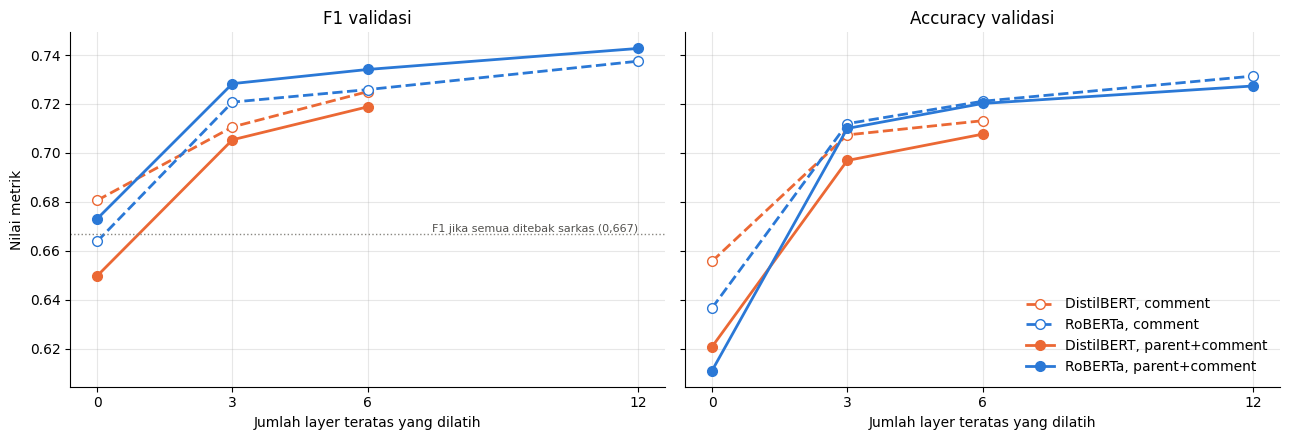

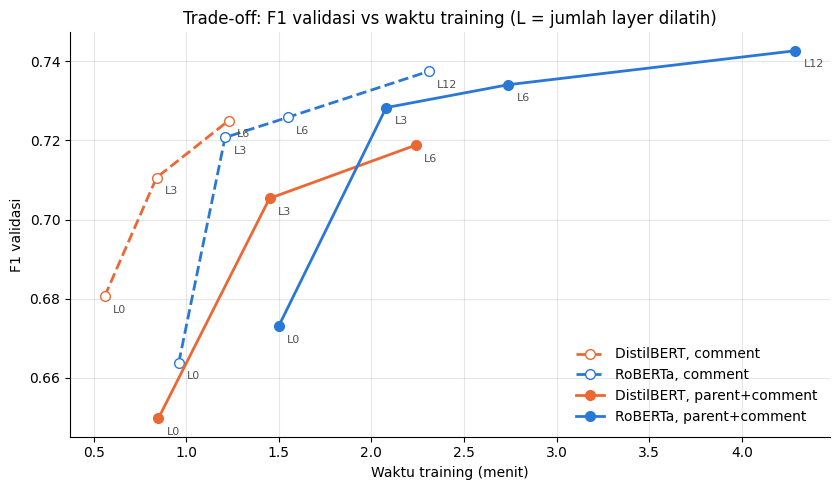

In [54]:
WARNA = {"roberta": "#2a78d6", "distilbert": "#eb6834"}          # warna = model
GAYA = {"parent+comment": dict(linestyle="-", markerfacecolor=None),   # garis penuh = parent + comment
        "comment": dict(linestyle="--", markerfacecolor="white")}      # garis putus = comment saja
NAMA = {"roberta": "RoBERTa", "distilbert": "DistilBERT"}

def garis(ax, x, y, label_titik=False):
    for (inp, model), g in best.groupby(["Input", "Model"]):
        style = {**GAYA[inp], "markerfacecolor": GAYA[inp]["markerfacecolor"] or WARNA[model]}
        ax.plot(g[x], g[y], marker="o", markersize=7, linewidth=2, color=WARNA[model],
                label=f"{NAMA[model]}, {inp}", **style)
        if label_titik:
            for _, r in g.iterrows():
                ax.annotate(f"L{r['Layer dilatih']}", (r[x], r[y]), textcoords="offset points",
                            xytext=(6, -12), fontsize=8, color="#52514e")
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# Grafik 1: performa per jumlah layer yang dilatih
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metrik in zip(axes, ["F1", "Accuracy"]):
    garis(ax, "Layer dilatih", metrik)
    ax.set_title(f"{metrik} validasi")
    ax.set_xlabel("Jumlah layer teratas yang dilatih")
    ax.set_xticks([0, 3, 6, 12])
axes[0].axhline(2 / 3, color="#898781", linewidth=1, linestyle=":")
axes[0].text(12, 2 / 3, "F1 jika semua ditebak sarkas (0,667)", ha="right", va="bottom", fontsize=8, color="#52514e")
axes[0].set_ylabel("Nilai metrik")
axes[1].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# Grafik 2: trade-off performa vs biaya training
fig, ax = plt.subplots(figsize=(8.5, 5))
garis(ax, WAKTU, "F1", label_titik=True)
ax.set_title("Trade-off: F1 validasi vs waktu training (L = jumlah layer dilatih)")
ax.set_xlabel("Waktu training (menit)")
ax.set_ylabel("F1 validasi")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


#### Insight
- **Grafik 1:** semua garis naik tajam dari level 0 ke 3, lalu melandai. Titik-titik level 0 berada di sekitar garis batas 0,667, sedangkan level 3 ke atas sudah jelas di atasnya.
- **Grafik 1, sisi accuracy:** garis putus-putus (comment saja) berada sedikit di atas atau berimpit dengan garis penuh. Jadi dari sisi accuracy, parent tidak menambah apa-apa.
- **Grafik 2:** titik paling kanan atas adalah RoBERTa full dengan parent + comment, yaitu yang terbaik (0,7427) sekaligus termahal (4,29 menit). Garis putus-putus mencapai F1 yang hampir sama dengan waktu kira-kira setengahnya, karena input comment saja jauh lebih pendek.
- **Grafik 2:** pada input parent + comment, RoBERTa dengan 3 layer (2,08 menit, F1 0,7283) sedikit lebih cepat dan lebih baik daripada DistilBERT full (2,24 menit, F1 0,7188). Pada input comment saja keduanya hampir sama (RoBERTa 3 layer: 1,21 menit, 0,7208; DistilBERT full: 1,23 menit, 0,7250). Tetapi grafik ini hanya soal biaya training; untuk kecepatan prediksi, DistilBERT tetap dua kali lebih cepat.

## 15. Kesimpulan & Langkah Selanjutnya

### Kesimpulan
1. **Semua 18 percobaan berjalan lancar** di RTX 5070 Ti, dan hasilnya konsisten dengan pilot.
2. **RoBERTa vs DistilBERT:** pada skenario utama proposal, RoBERTa mendapat F1 0,743 dan DistilBERT 0,719. DistilBERT kira-kira dua kali lebih ringan di waktu training (1,92×), memori (1,92×), dan latensi (1,91–2,00×).
3. **Comment vs parent + comment:** di data pilot, parent belum terbukti membantu, padahal biayanya 1,5–1,9 kali lipat.
4. **Jumlah layer:** melatih 3 layer teratas sudah mendekati full fine-tuning (selisih F1 sekitar 0,015) dengan kira-kira setengah biaya training. Hanya melatih lapisan klasifikasi (level 0) tidak cukup.
5. **F1 perlu dibaca bersama accuracy,** terutama untuk level 0 yang nilainya di sekitar batas 0,667.

### Keterbatasan
- Data latih hanya 40.000 pasangan, seperempat dari data latih penuh.
- Setiap percobaan hanya dijalankan satu kali dengan satu seed, sehingga selisih kecil (di bawah kira-kira 0,01) belum bisa dipercaya.
- Dinilai pada data validasi, bukan data test.
- Learning rate 3e-5 berasal dari pilot dengan full fine-tuning, dan dipakai begitu saja untuk level 3 dan 6.
- Level 0 belum selesai belajar dalam 3 epoch.

### Pertanyaan untuk dosen
1. Apakah level layer 0, 3, 6, dan 12 sudah sesuai dengan yang dimaksud?
2. Parent hampir tidak membantu di data pilot. Apakah skenario comment saja tetap dilaporkan sebagai pembanding?
3. Level 0 dilaporkan apa adanya, atau diberi epoch lebih banyak?
4. Untuk run final, apakah semua 14 kombinasi dijalankan atau cukup sebagian?
5. Apakah learning rate perlu dicari untuk tiap level layer?
6. Proposal menulis "dilatih tiga kali menggunakan random seed yang sama". Apakah maksudnya tiga seed berbeda (42, 43, 44) dengan pembagian data yang tetap?
7. Selain F1 kelas sarkas, apakah perlu melaporkan macro-F1?
8. Apakah skenario tambahan ini perlu ditulis di laporan sebagai pelengkap proposal?

### Langkah selanjutnya
1. Menjalankan ulang dengan data latih penuh (160.000) untuk mengecek temuan soal parent.
2. Setelah masukan dosen: run final dengan tiga seed, model dari epoch terbaik disimpan, dan penilaian akhir dilakukan di data test.
3. Menyusun analisis trade-off akhir: *performance loss*, *efficiency gain*, dan *speedup factor*.